In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

In [2]:
current_path = Path().cwd()
project_dir = current_path.parents[1]
data_path = project_dir / "data" / "data_processed"
file_path = data_path / "cassava" / "price_avg.csv"

wide = pd.read_csv(file_path)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

In [3]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [4]:
SEQ_LEN = 12
PRED_LEN = 12


class SeqDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        seq = self.data[idx : idx + self.seq_len]
        targ = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return torch.from_numpy(seq).unsqueeze(-1), torch.from_numpy(targ)


In [5]:
ds = SeqDataset(series, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

In [6]:
class LSTMRegressor(nn.Module):
    def __init__(self, hidden=32, layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True
        )
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
model = LSTMRegressor()
crit = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 300
for epoch in range(1, EPOCHS + 1):
    for seq, targ in loader:
        opt.zero_grad()
        pred = model(seq)
        loss = crit(pred.squeeze(), targ[:, 0])
        loss.backward()
        opt.step()
    if epoch % 50 == 0:
        print(f"epoch {epoch:>3}/{EPOCHS}  loss={loss.item():.5f}")

epoch  50/300  loss=0.00797
epoch 100/300  loss=0.00269
epoch 150/300  loss=0.00162
epoch 200/300  loss=0.00122
epoch 250/300  loss=0.00118
epoch 300/300  loss=0.00118


In [8]:
model.eval()
with torch.no_grad():
    window = torch.from_numpy(series[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1)
    preds = []
    for _ in range(PRED_LEN):
        nxt = model(window)
        preds.append(nxt.item())
        window = torch.cat([window[:, 1:, :], nxt.unsqueeze(0)], dim=1)

preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

gregorian_year = 2567 - 543
forecast = pd.Series(
    preds,
    index=pd.date_range(f"{gregorian_year}-01-01", periods=12, freq="MS"),
    name="forecast_price",
)

print("--- Forecast for 2567 ---")
print(forecast.round(2))

--- Forecast for 2567 ---
2024-01-01    3.49
2024-02-01    3.28
2024-03-01    3.17
2024-04-01    3.08
2024-05-01    2.99
2024-06-01    2.90
2024-07-01    2.82
2024-08-01    2.75
2024-09-01    2.68
2024-10-01    2.62
2024-11-01    2.56
2024-12-01    2.51
Freq: MS, Name: forecast_price, dtype: float64


In [9]:
cmp = pd.concat([future["price"].rename("actual"), forecast], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))


--- Actual vs Forecast (debug view) ---
            actual  forecast_price
2024-01-01    3.65            3.49
2024-02-01    3.65            3.28
2024-03-01    3.57            3.17
2024-04-01    3.24            3.08
2024-05-01    3.19            2.99
2024-06-01    3.09            2.90
2024-07-01    3.06            2.82
2024-08-01    2.95            2.75
2024-09-01    2.86            2.68
2024-10-01    2.65            2.62
2024-11-01    2.60            2.56
2024-12-01    2.32            2.51


In [10]:
error = cmp["actual"] - cmp["forecast_price"]
abs_error = error.abs()
pct_error = (error / cmp["actual"]) * 100


print("\n--- Monthly Errors ---")
error_df = pd.DataFrame(
    {
        "actual": cmp["actual"],
        "forecast": cmp["forecast_price"],
        "error": error,
        "abs_error": abs_error,
        "pct_error": pct_error,
    }
)
print(error_df.round(4))

average_percent_error = pct_error.mean()
print(f"\n--- Average Percent Error: {average_percent_error:.2f}% ---")


--- Monthly Errors ---
            actual  forecast   error  abs_error  pct_error
2024-01-01    3.65    3.4907  0.1593     0.1593     4.3637
2024-02-01    3.65    3.2847  0.3653     0.3653    10.0075
2024-03-01    3.57    3.1664  0.4036     0.4036    11.3060
2024-04-01    3.24    3.0837  0.1563     0.1563     4.8225
2024-05-01    3.19    2.9921  0.1979     0.1979     6.2042
2024-06-01    3.09    2.9009  0.1891     0.1891     6.1186
2024-07-01    3.06    2.8208  0.2392     0.2392     7.8186
2024-08-01    2.95    2.7487  0.2013     0.2013     6.8225
2024-09-01    2.86    2.6817  0.1783     0.1783     6.2325
2024-10-01    2.65    2.6197  0.0303     0.0303     1.1435
2024-11-01    2.60    2.5625  0.0375     0.0375     1.4418
2024-12-01    2.32    2.5098 -0.1898     0.1898    -8.1799

--- Average Percent Error: 4.84% ---


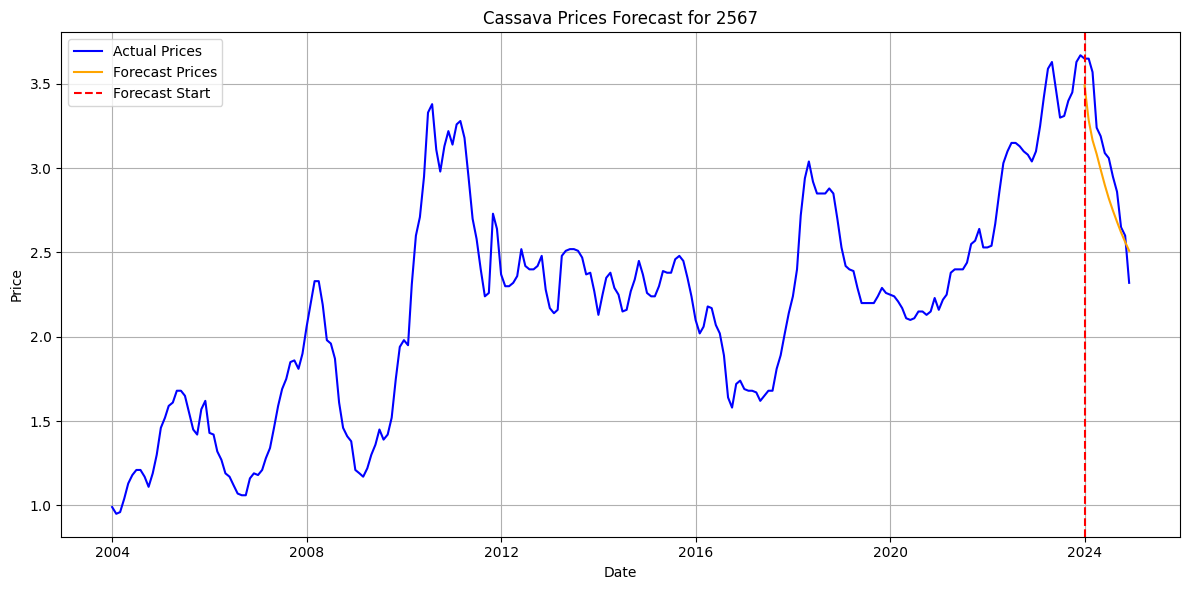

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(forecast.index, forecast, label="Forecast Prices", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_year}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.title("Cassava Prices Forecast for 2567")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("cassava_prices_forecast.png")
plt.show()